## Cell type frequency box plots after treatment

In [1]:
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu

import seaborn as sb
import matplotlib.pyplot as plt

# making sure plots & clusters are reproducible
np.random.seed(42)

In [2]:
## path variables
data_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/'
out_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig3/box_plots_frequencies/'

In [3]:
## plotting variables
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## load correlation table
freq_df = pd.read_csv(data_dir + '240830_cell_type_frequencies.csv', sep =',', index_col = 0)

In [5]:
freq_df.head(5)

,treatment,time_point,ashcroft_score,AT1,AT2,AT2 activated,Krt8+ ADI,Basal,Club/Ciliated,Ciliated,...,Cd8+ T cells,Cd4+/Cd8+ T cells,T reg cells,Th2 cells,Th17 cells,Themis+ T cells,Proliferating T cells,NK T cells,NK cells,max_body_weight_loss
d100BLM_Combo48,Combo,d10,3.0000,0.010585,0.0,0.004457,0.020613,0.000557,0.007521,0.004457,...,0.001671,0.047354,0.006407,0.002507,0.022006,0.000279,0.001114,0.020891,0.008357,7.6
d100BLM_G120528,GLPG1205,d10,2.5000,0.005167,0.0,0.007046,0.019023,0.000000,0.000470,0.007046,...,0.019962,0.026069,0.012682,0.004932,0.009864,0.000000,0.005402,0.035463,0.012212,2.0
d100BLM_G169038,GLPG1690,d10,2.6875,0.001171,0.0,0.002049,0.003220,0.000000,0.000000,0.008489,...,0.037763,0.008489,0.033665,0.006440,0.030152,0.000293,0.004684,0.067037,0.024883,4.1
d100BLM_Nint58,Nintedanib,d10,3.5000,0.000569,0.0,0.007110,0.007964,0.000000,0.003697,0.002560,...,0.000284,0.071388,0.012799,0.004551,0.010808,0.000000,0.002844,0.022184,0.006826,7.2
d10BLM10,vehicle,d10,2.0000,0.000574,0.0,0.000574,0.005737,0.000000,0.001147,0.000574,...,0.053930,0.028686,0.024670,0.006311,0.023523,0.000000,0.008032,0.075731,0.014917,3.5


### For future reference: add one summary column for granulocytes

In [6]:
freq_df['Granulocytes'] = freq_df['Basophils'] + freq_df['Eosinophils'] + freq_df['Immature Neutrophils'] + freq_df['Intermediate Neutrophils'] + freq_df['Mature Neutrophils'] + freq_df['IFN-primed Neutrophils']

### Filter frequency table
Cell types detected in at least x samples

In [7]:
## our approach: cell type with non-zero count in fewer than 25 samples
## our rationale: we have max. 18 samples per treatment, if we have full depletion or disease-specificity of one cell type we still want to include it, while also accounting for some variability/dropout, so threshold has to be higher

robust_ct = []

for ct in freq_df.columns[3:-1].to_list():
    n_zeros = sum(freq_df[ct] == 0)
    #print(f'{ct} not detected in {n_zeros} samples')
    if n_zeros < 25:
        robust_ct.append(ct)

In [8]:
cols_to_keep = robust_ct
cols_to_keep.append('treatment')
cols_to_keep.append('time_point')
cols_to_keep.append('Granulocytes')

In [9]:
freq_df = freq_df[cols_to_keep]
freq_df.head(5)

,AT1,AT2 activated,Krt8+ ADI,Ciliated,Aerocyte capillary EC,Transitional capillary EC,General capillary EC,Vwa1+/Col15a1+ ectopic capillary EC,Arterial EC,Venous EC,...,T reg cells,Th2 cells,Th17 cells,Proliferating T cells,NK T cells,NK cells,max_body_weight_loss,treatment,time_point,Granulocytes
d100BLM_Combo48,0.010585,0.004457,0.020613,0.004457,0.025070,0.004178,0.087187,0.047632,0.003064,0.006407,...,0.006407,0.002507,0.022006,0.001114,0.020891,0.008357,7.6,Combo,d10,0.163510
d100BLM_G120528,0.005167,0.007046,0.019023,0.007046,0.018553,0.003288,0.116956,0.022076,0.003523,0.008924,...,0.012682,0.004932,0.009864,0.005402,0.035463,0.012212,2.0,GLPG1205,d10,0.077266
d100BLM_G169038,0.001171,0.002049,0.003220,0.008489,0.010539,0.000293,0.118267,0.036593,0.002049,0.004977,...,0.033665,0.006440,0.030152,0.004684,0.067037,0.024883,4.1,GLPG1690,d10,0.038349
d100BLM_Nint58,0.000569,0.007110,0.007964,0.002560,0.013652,0.002275,0.118316,0.047782,0.004266,0.008532,...,0.012799,0.004551,0.010808,0.002844,0.022184,0.006826,7.2,Nintedanib,d10,0.094141
d10BLM10,0.000574,0.000574,0.005737,0.000574,0.003442,0.000000,0.022949,0.011474,0.005164,0.000574,...,0.024670,0.006311,0.023523,0.008032,0.075731,0.014917,3.5,vehicle,d10,0.041308


In [10]:
## robust disease associated cell states
cell_types_of_interest = ['Proliferating AM',
                          'Cthrc1+ Myofibroblasts',
                          'pDC',
                          'Krt8+ ADI',
                          'Vwa1+/Col15a1+ ectopic capillary EC',
                          'M2 Macrophages',
                          'Transitional Monocytes',
                          'Eosinophils',
                          'Lyve1+/Cd163+ IM',
                          'Granulocytes']

### Prepare data for visualization

In [11]:
freq_df['treatment'].unique()

array(['Combo', 'GLPG1205', 'GLPG1690', 'Nintedanib', 'vehicle', 'none'],
      dtype=object)

In [12]:
## updata metadata
treatment_dict = {
    'none':'Control',
    'vehicle':'BLM+PBS',
    'Nintedanib':'BLM+Nintedanib',
    'GLPG1205':'BLM+GLPG1205',
    'GLPG1690':'BLM+GLPG1690',
    'Combo':'BLM+Combo'
    
}
freq_df['treatment'] = freq_df['treatment'].map(treatment_dict)

In [13]:
treatments = ['Control','BLM+PBS','BLM+Nintedanib','BLM+GLPG1205','BLM+GLPG1690','BLM+Combo']
timepoints = ['d10','d21']

In [14]:
## color palette for plotting
treatment_colors = ['#D3D3D3', '#606060', '#2E59A8', '#FFA500','#C93333', '#20B2AA']

In [15]:
## define baseline for stat testing
baseline = 'BLM+PBS'

In [16]:
# Function to calculate p-values and significance stars
def add_significance(df, baseline_treatment, to_test, treatments):
    comparisons = []
    for treatment in treatments:
        if treatment != baseline_treatment:
            _, p_value = mannwhitneyu(
                df[df['treatment'] == baseline_treatment][to_test],
                df[df['treatment'] == treatment][to_test]
            )
            print(p_value)
            
            if p_value < 0.001:
                comparisons.append((treatment, f'*** \n(p = {round(p_value, 3)})', p_value))
            elif p_value < 0.01:
                comparisons.append((treatment, f'** \n(p = {round(p_value, 3)})', p_value))
            elif p_value < 0.05:
                comparisons.append((treatment, f'* \n(p = {round(p_value, 3)})', p_value))
            else:
                comparisons.append((treatment, f'n.s.', p_value))
    return comparisons

0.0011137631082726795
0.15933381681434866
0.4543759676970297
0.09424681096710075
0.27191282088637114


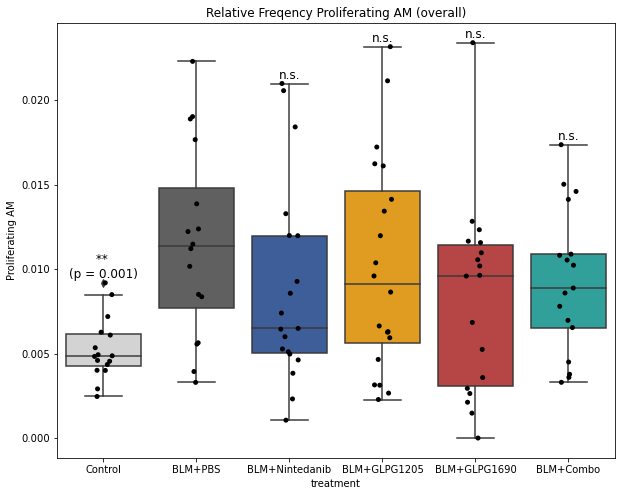

0.04988344988344988
0.5414232825997531
0.6964669317610493
0.8148087206910737
0.10489510489510488


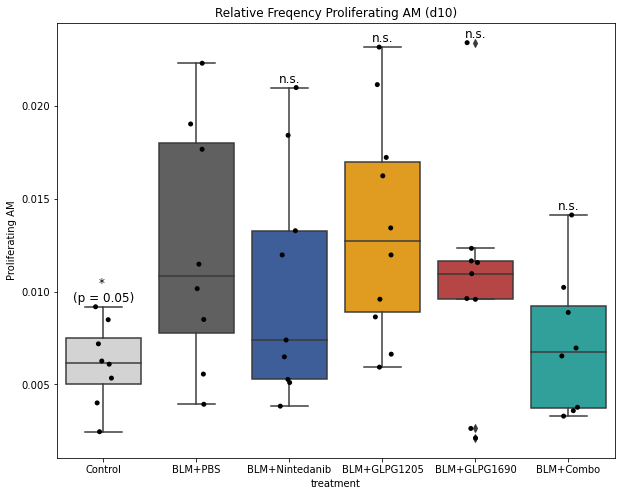

0.006993006993006993
0.17281411399058458
0.12198912198912198
0.059234882764294526
1.0


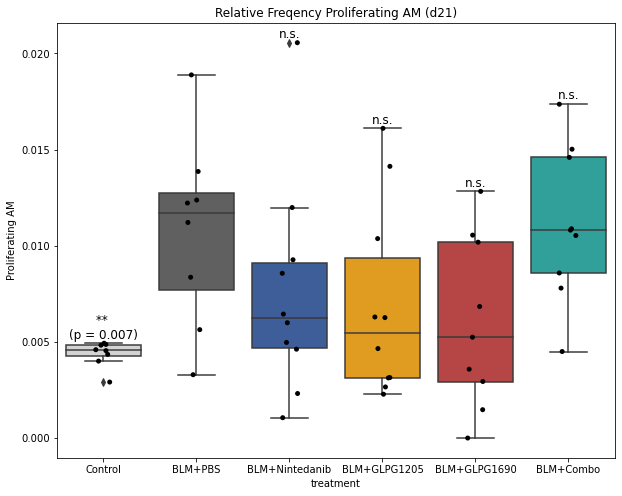

1.637799231755667e-06
0.868488951440579
0.8986625149446985
0.23949069548101642
0.7457682534975447


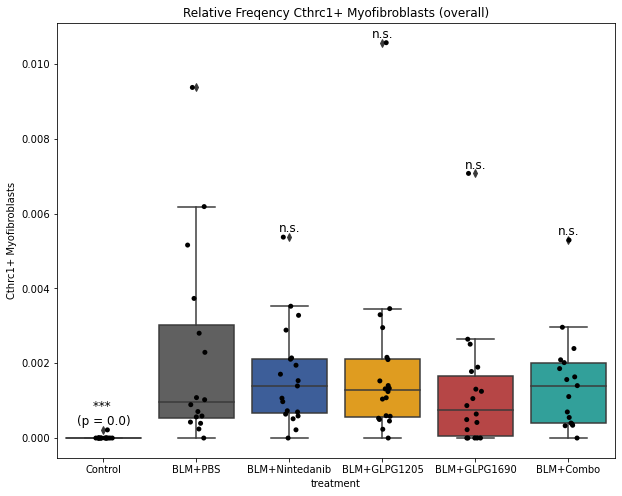

0.0024552337317397506
0.21068182941043767
0.32813349948087955
0.4076000389052804
0.32820512820512815


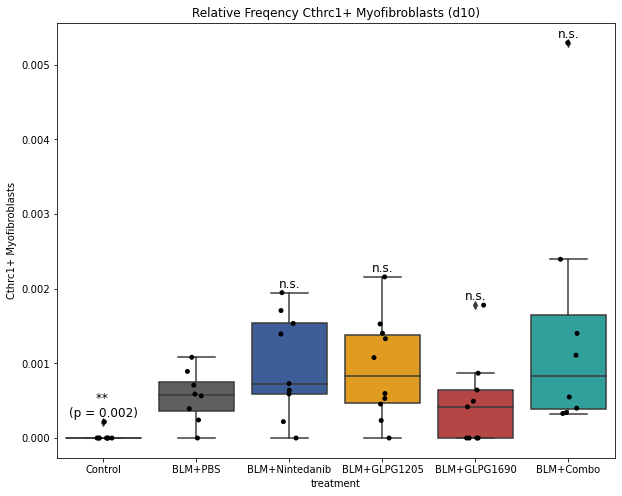

0.00040993253186482205
0.2742812742812743
0.40824534942182
0.16717400246812014
0.046400658165364046


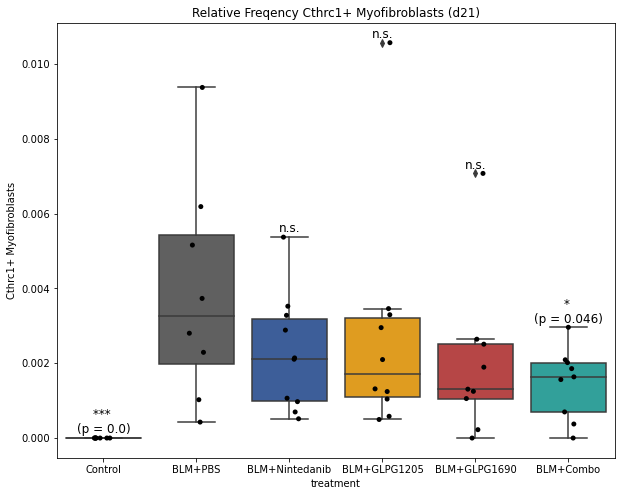

1.5449101737495915e-06
0.052729628765175465
0.836062788872005
0.5691497940860235
0.6525129922885164


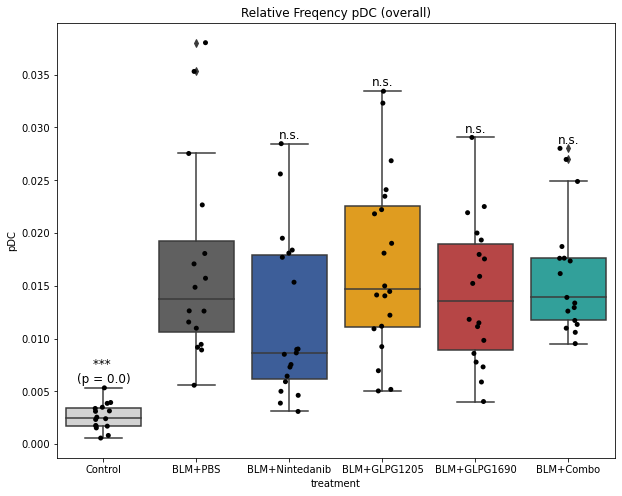

0.0001554001554001554
0.4234471410941999
0.7618264088852323
0.5414232825997531
0.7209013209013208


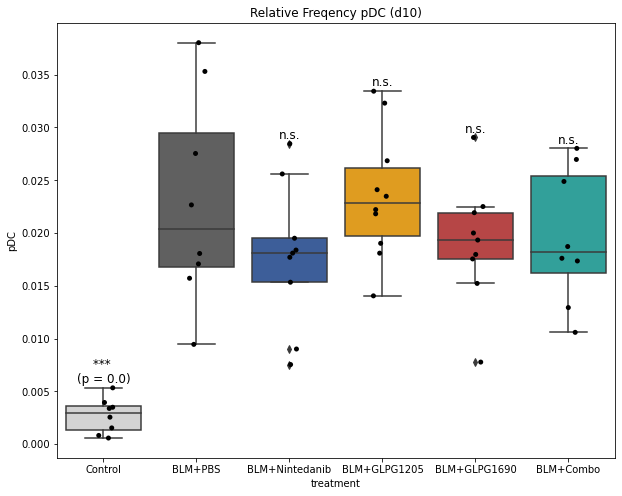

0.0001554001554001554
0.0020567667626491155
0.8967503085150144
0.4234471410941999
0.16717400246812014


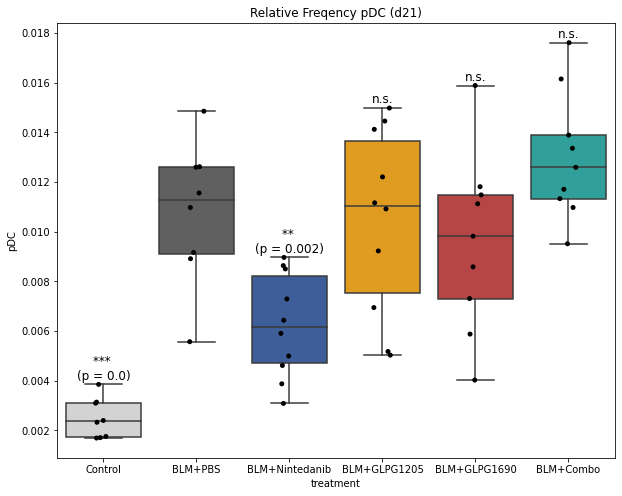

9.77567721800023e-07
0.9077345052112101
0.5993819586698879
0.19570931842465422
0.4602415787643992


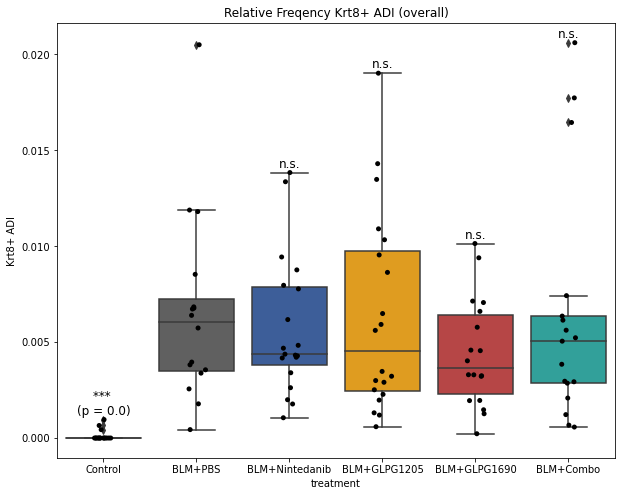

0.0007853381460163174
1.0
0.6334384569678687
0.1995886466474702
0.7209013209013208


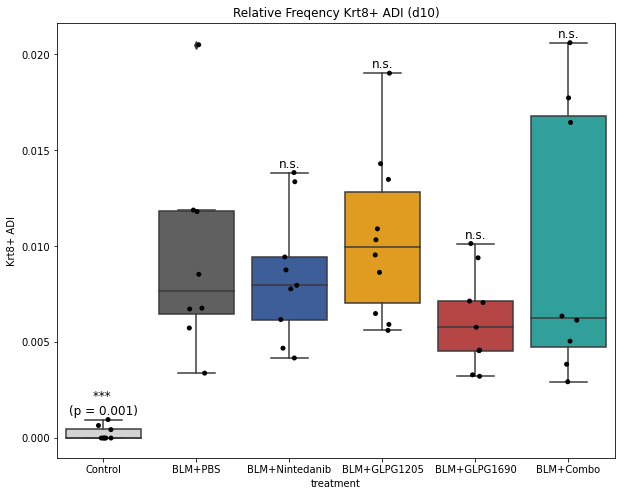

0.00040993253186482205
1.0
0.10110151286621874
0.3212669683257919
0.6729740847387906


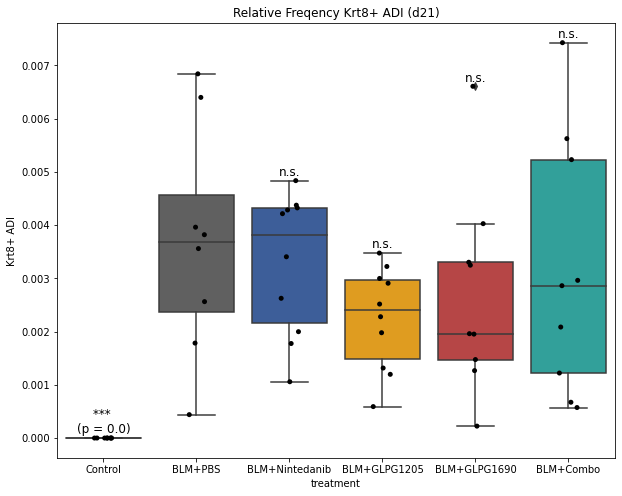

1.5449101737495915e-06
0.38021366026294423
0.7866958655639658
0.23390371367256635
0.8429507908219149


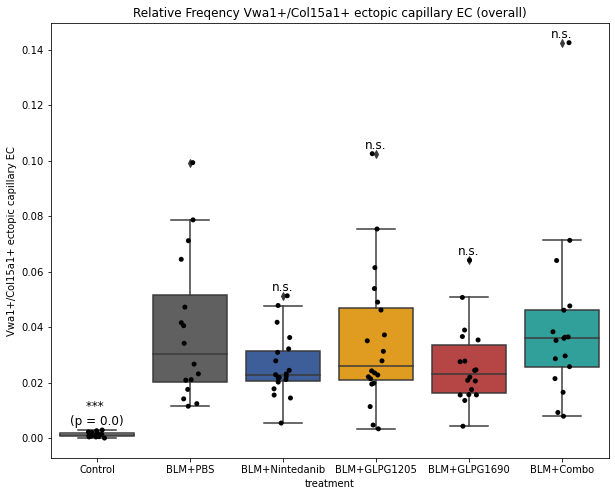

0.0001554001554001554
0.07445495680789799
0.17281411399058458
0.5414232825997531
0.3822843822843822


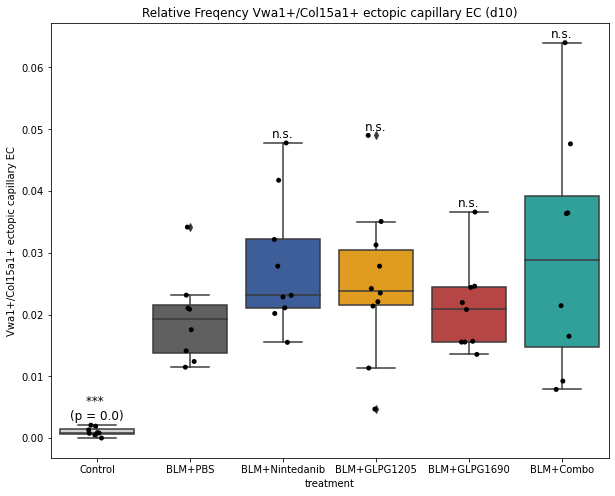

0.0001554001554001554
0.0013711778417660769
0.236985236985237
0.02064993829699712
0.1995886466474702


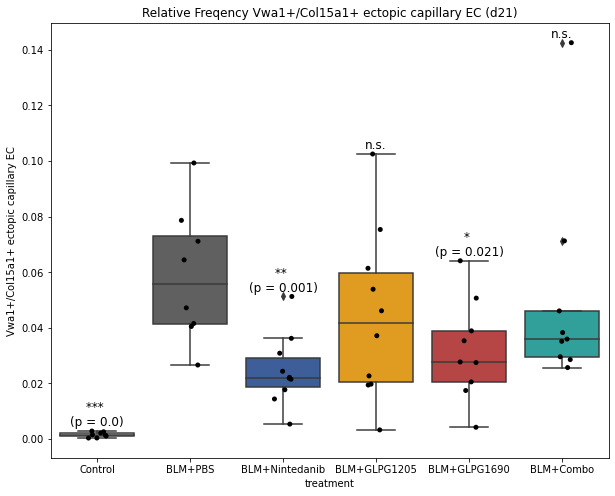

1.5313577763511972e-06
0.5401433614641258
0.5774418757515851
0.016485863525968578
0.9282436914627462


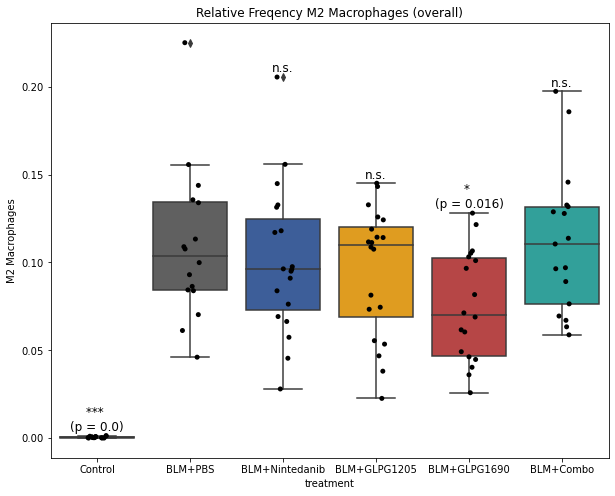

0.000930972271575002
0.8883587001234061
0.8285570638511814
0.2358700123406006
0.5053613053613053


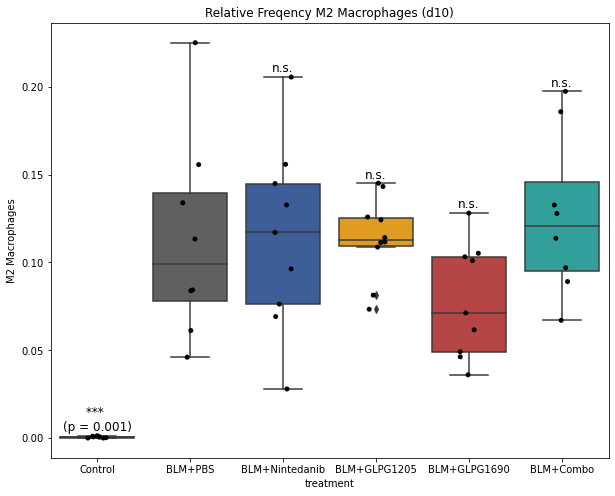

0.0001554001554001554
0.17281411399058458
0.14571049865167512
0.03595228301110654
0.6058412176059235


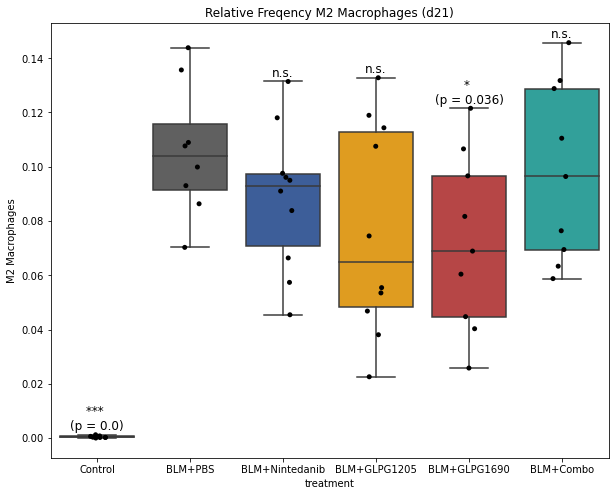

3.92182811142228e-07
0.02536653249162931
0.4935683542483178
0.0020083992614581335
0.8429507908219149


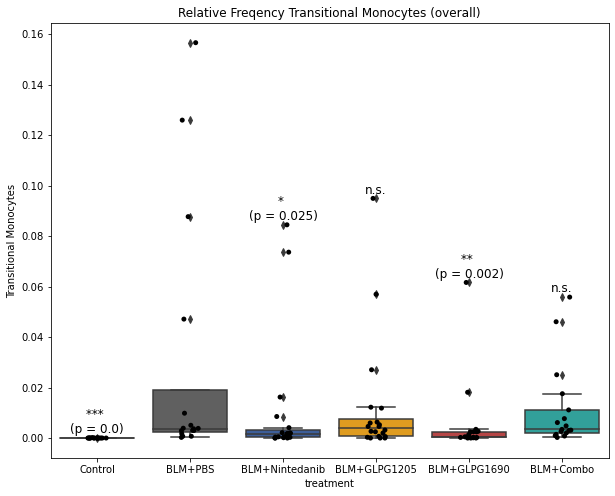

0.0005535347656685908
0.16717400246812014
0.7618264088852323
0.011106540518305223
0.5737373737373737


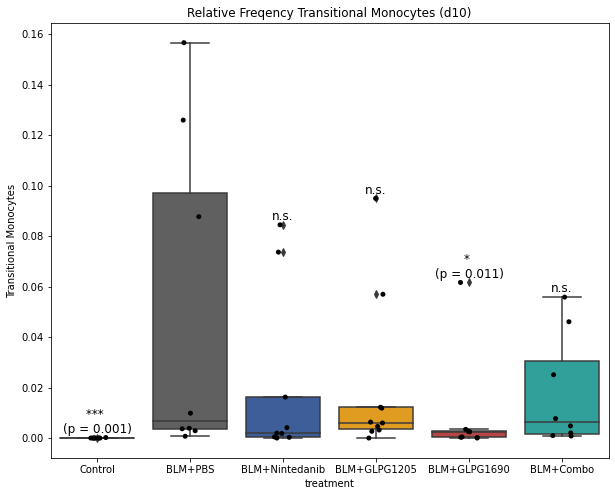

0.00040993253186482205
0.06839228293213676
0.35059734998094105
0.030281293470426608
0.7429864253393665


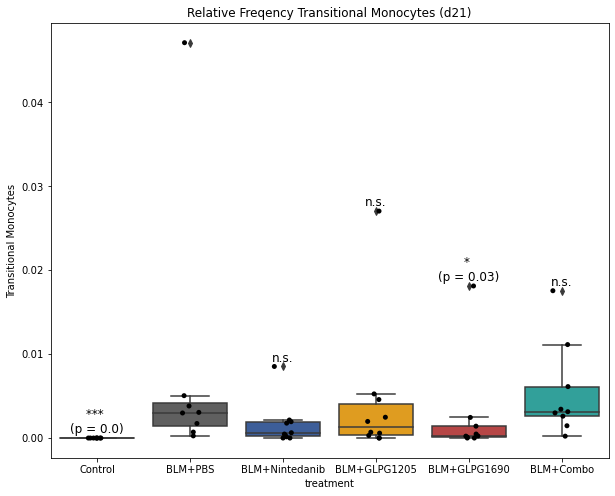

1.3640327198293456e-06
0.03849152312012653
0.1565736254753674
0.008302823597967862
0.6267574865832262


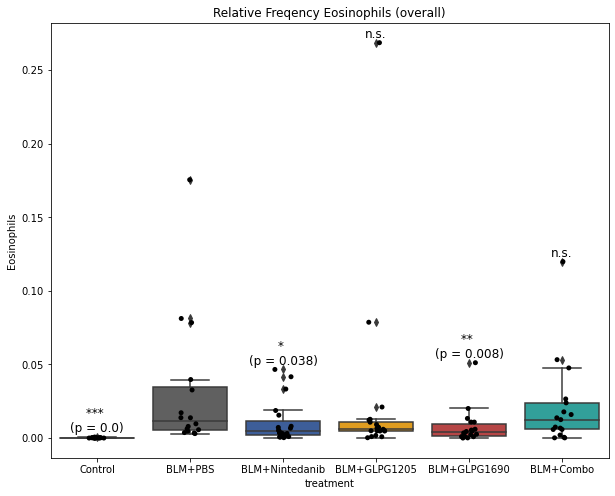

0.0009068567509923489
0.3212669683257919
0.35993418346359524
0.03595228301110654
0.2786324786324786


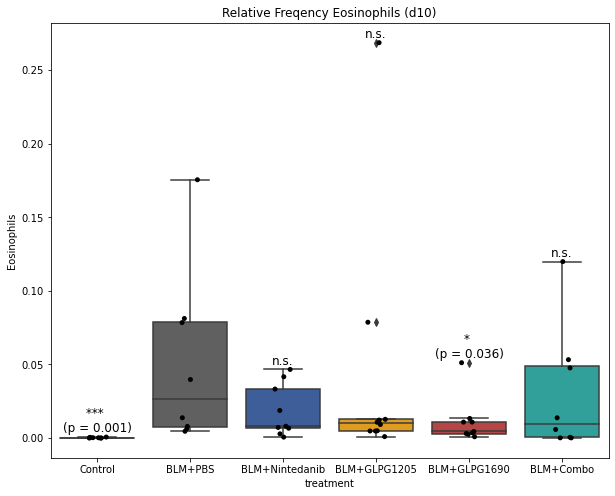

0.0008598969101507296
0.026646556058320763
0.35993418346359524
0.07445495680789799
0.4807075277663513


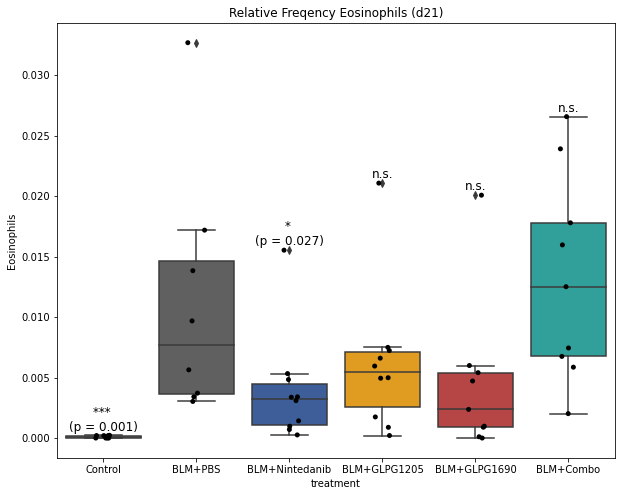

0.003090599405991815
0.34530799504008103
0.3159451110985233
0.36053986471650135
0.814874428740246


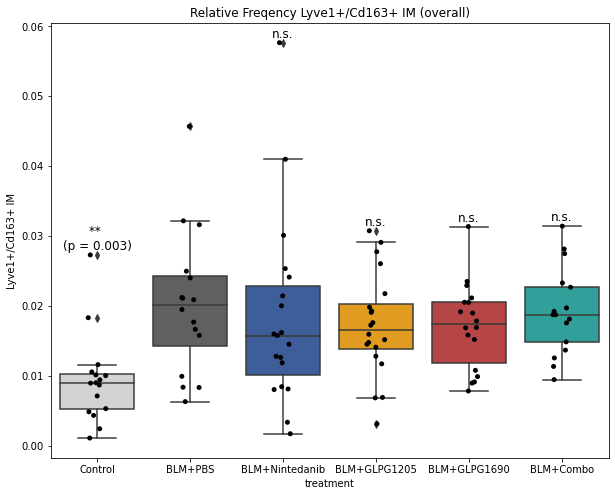

0.32820512820512815
0.7429864253393665
0.3154166095342566
0.5414232825997531
0.10489510489510488


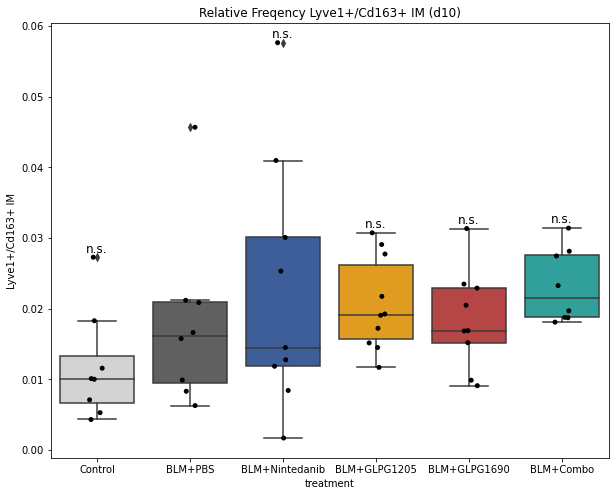

0.0029526029526029526
0.03427944604415192
0.020521961698432286
0.059234882764294526
0.03595228301110654


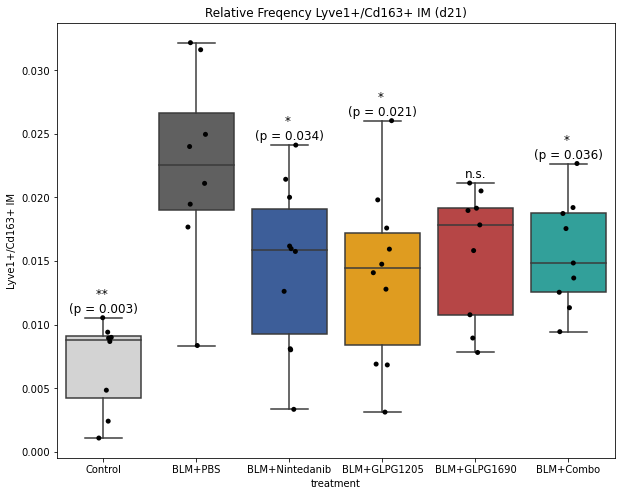

0.6108921432274232
0.03269503207708429
0.3642385421652301
0.12468661770537769
0.3972656001356304


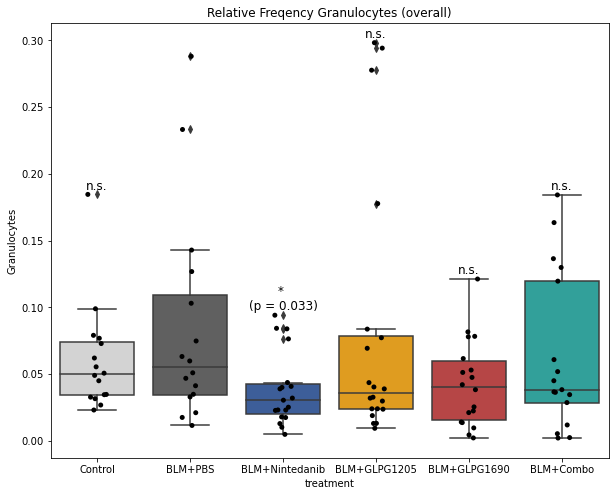

0.037917637917637914
0.059234882764294526
0.0675990675990676
0.015220074043603454
0.19487179487179485


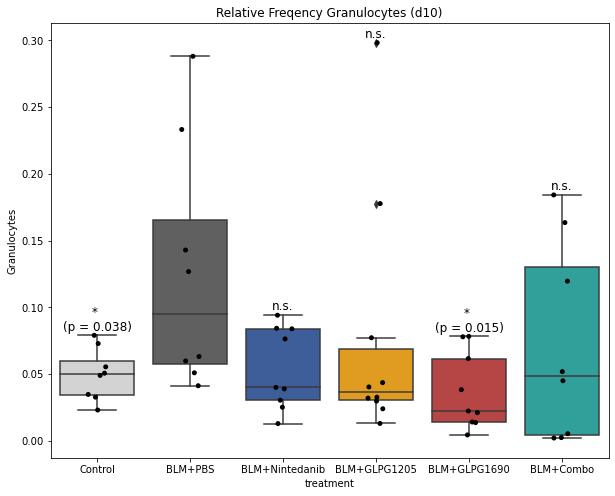

0.2786324786324786
0.20307143836555602
0.8285570638511814
0.6729740847387906
0.4234471410941999


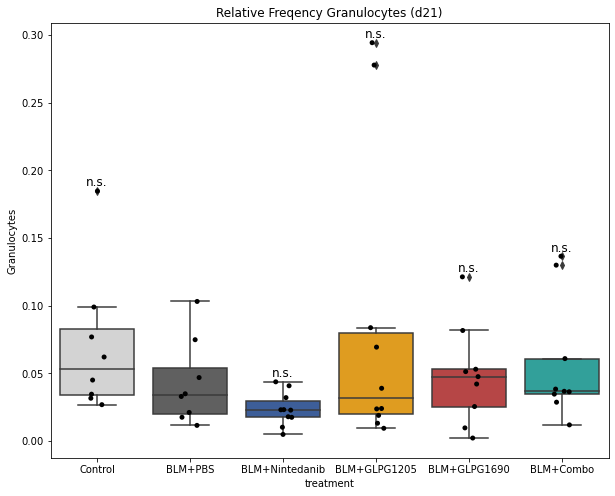

In [17]:
for ct in cell_types_of_interest:
    
    ## ref label for scipy stats
    to_test = ct
    
    ## ct label to save as .pdf without issues
    ct_label = ct.replace(' ','_').replace('/','_')
    
    ## overall frequency changes
    plt.figure(figsize=(10, 8))
    ax = sb.boxplot(x='treatment', y=ct, data=freq_df, order=treatments, palette=treatment_colors)
    
    ## add individual data points as black dots
    sb.stripplot(x='treatment', y=ct, data=freq_df, order=treatments, color='black', size=5, jitter=True, ax=ax)
    plt.title(f'Relative Freqency {ct} (overall)')
    
    ## add significance stars
    comparisons = add_significance(freq_df, baseline, to_test, treatments)
    for treatment, significance, _ in comparisons:
        y_max = freq_df[freq_df['treatment'] == treatment][ct].max()
        ax.annotate(significance, xy=(treatments.index(treatment), y_max), 
                    xytext=(0, 5), textcoords='offset points', ha='center', fontsize=12, color='black')
    
    ## save figure as PDF
    plt.savefig(out_dir + f'frequency_boxplot_{ct_label}_overall.pdf')
    plt.show()
    
    
    for t in timepoints:
    
        ## subset data
        df = freq_df[freq_df['time_point'] == t]
            
        ## overall boxplot
        plt.figure(figsize=(10, 8))
        ax = sb.boxplot(x='treatment', y=ct, data=df, order=treatments, palette=treatment_colors)
        
        ## add individual data points as black dots
        sb.stripplot(x='treatment', y=ct, data=df, order=treatments, color='black', size=5, jitter=True, ax=ax)
        plt.title(f'Relative Freqency {ct} ({t})')
    
        ## add significance stars
        comparisons = add_significance(df, baseline, to_test, treatments)
        for treatment, significance, _ in comparisons:
            y_max = df[df['treatment'] == treatment][ct].max()
            ax.annotate(significance, xy=(treatments.index(treatment), y_max), 
                        xytext=(0, 5), textcoords='offset points', ha='center', fontsize=12, color='black')
        
        ## save figure as PDF
        plt.savefig(out_dir + f'frequency_boxplot_{ct_label}_{t}.pdf')
        plt.show()